In [1]:
!pip install --upgrade git+https://github.com/ColibrITD-SAS/landscape_tools@dev

  Cloning https://github.com/ColibrITD-SAS/landscape_tools (to revision dev) to /tmp/pip-req-build-ow3qgz13
  Running command git clone --filter=blob:none --quiet https://github.com/ColibrITD-SAS/landscape_tools /tmp/pip-req-build-ow3qgz13
  Running command git checkout -b dev --track origin/dev
  Switched to a new branch 'dev'
  branch 'dev' set up to track 'origin/dev'.
  Resolved https://github.com/ColibrITD-SAS/landscape_tools to commit 50e6c6bbf19b625f9540e7c5c686c800e0c75fb2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for landscape-tools: filename=landscape_tools-0.1.dev71+g50e6c6bbf-py3-none-any.whl size=42548 sha256=548272e3f1e54ab434ec86a404985e16c47a94a4ac9d908796dd368df0210302
  Stored in directory: /tmp/pip-ephem-wheel-cache-srpbe1hu/wheels/5f/37/aa/638d6bbcebd7da1752c19f840e034c8dc424e871754710f71e
Successfully built landscape-tools
  Attempting uninstall: landscape-t

# Imports

In [1]:
from landscape_tools import landscape_visualization as lv
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector

from scipy.optimize import minimize

/home/gabriel/Desktop/public/landscape_visualisation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/gabriel/Desktop/public/landscape_visualisation/.venv/lib/python3.12/site-packages/vcs_versioning/_config.py:261: UserWarning: relative_to is expected to be a file, it's the directory /home/gabriel/Desktop/public/landscape_visualisation/.venv/lib/python3.12/site-packages
assuming the parent directory was passed
  return _check_absolute_root(self.root, self.relative_to)


# Example of a problem

## Probability distribution

In [2]:
def get_prob_distribution(params, ansatz, theta_params):

    param_dict = dict(zip(theta_params, params))                               
    # param_dict = {
    #     θ_0: 0.5,
    #     θ_1: 1.2
    # }

    bound_circuit = ansatz.assign_parameters(param_dict, inplace=False)

    state = Statevector.from_instruction(bound_circuit)
    probs = state.probabilities()

    return np.asarray(probs, dtype=float)

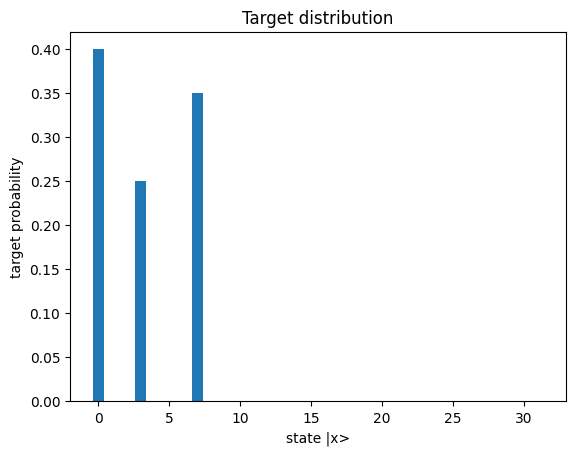

In [3]:
n_qubits = 5
dim = 2 ** n_qubits

p_target = np.zeros(dim)

# index 0 -> |000>, index 1 -> |001>, ..., index 7 -> |111>
p_target[0] = 0.40  # |000>
p_target[3] = 0.25  # |011>
p_target[7] = 0.35  # |111>

p_target = p_target / p_target.sum()    # normalize to ensure probabilities sum to 1

plt.bar(range(dim), p_target)
plt.xlabel("state |x>")
plt.ylabel("target probability")
plt.title("Target distribution")
plt.show()

## Quantum circuit

In [4]:
def build_hea_ansatz(n_qubits, n_layers):
    """
    Hardware Efficient Ansatz :
    - RY + RZ on each qubit
    - CNOT chain
    """
    qc = QuantumCircuit(n_qubits)

    n_params = 2 * n_qubits * n_layers
    theta = ParameterVector("θ", n_params)

    k = 0
    for _ in range(n_layers):
        for q in range(n_qubits):
            qc.ry(theta[k], q)
            k += 1
            qc.rz(theta[k], q)
            k += 1

        for q in range(n_qubits - 1):
            qc.cx(q, q + 1)

    return qc, theta

Number of parameters: 20


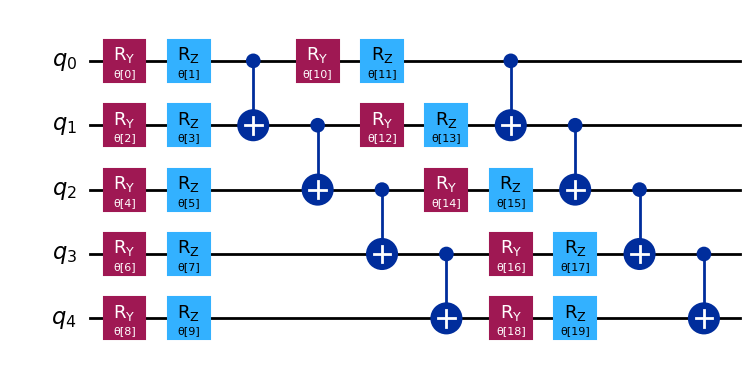

In [5]:
n_layers = 2

ansatz, theta_params = build_hea_ansatz(n_qubits, n_layers)

n_params = len(theta_params)

print("Number of parameters:", n_params)
ansatz.draw("mpl")

In [6]:
params_test = np.random.uniform(0, 2*np.pi, size=n_params)

p_test = get_prob_distribution(params_test, ansatz, theta_params)

print(p_test)
print("Sum =", p_test.sum())

[4.15733546e-02 4.79027262e-04 2.18155239e-02 2.58699642e-03
 3.18627740e-02 1.15789752e-03 4.74376622e-02 1.27015812e-02
 6.35063861e-02 6.16871848e-04 1.24594029e-04 1.86519929e-05
 1.38958465e-01 4.39509061e-03 2.76933548e-03 6.07373008e-04
 2.19354278e-02 2.71598660e-04 3.59414580e-02 4.23930927e-03
 6.44468459e-04 1.35939232e-05 6.81829126e-03 1.79047391e-03
 4.49730172e-01 4.25334428e-03 9.36537018e-03 9.47865071e-04
 8.45709466e-02 2.67229619e-03 5.03176102e-03 1.16203807e-03]
Sum = 0.9999999999999998


## Loss function

In [7]:
def mse_loss(params, ansatz, theta_params, p_target):
    p_model = get_prob_distribution(params, ansatz, theta_params)
    return np.sum((p_model - p_target) ** 2)

## Optimization

In [8]:
theta_history = []
loss_history = []

def objective(params):
    loss = mse_loss(params, ansatz, theta_params, p_target)
    return loss

def callback(params):
    theta_history.append(np.copy(params))
    loss_history.append(objective(params))

rng = np.random.default_rng(seed=42)

initial_params = rng.uniform(
    low=0.0,
    high=2*np.pi,
    size=n_params
)

In [9]:
result = minimize(
    objective,
    initial_params,
    method="COBYLA",
    callback=callback,
    options={
        "maxiter": 3000,
        "rhobeg": 0.5,
        "tol": 1e-6,
        "disp": True
    }
)

Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 3000   Least value of F = 0.141620402123945
The corresponding X is:
[3.96397799 5.37138149 5.96327055 3.11601968 1.03131752 5.19697268
 4.79735977 5.16748975 1.57076526 3.14163004 0.97168195 7.58971189
 4.00683035 4.66282188 1.77867564 1.18328303 3.3483333  0.15788304
 7.85394522 5.06004222]



theta_history shape: (2379, 20)
loss_history shape: (2379,)


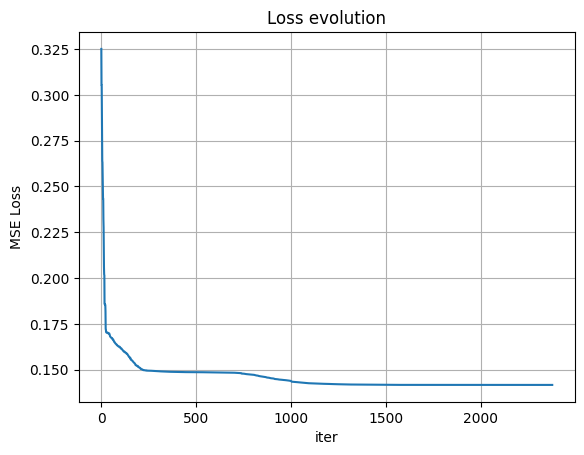

In [10]:
theta_history = np.array(theta_history)
loss_history = np.array(loss_history)

print("theta_history shape:", theta_history.shape)
print("loss_history shape:", loss_history.shape)
plt.plot(loss_history)
plt.xlabel("iter")
plt.ylabel("MSE Loss")
plt.title("Loss evolution")
plt.grid(True)
plt.show()

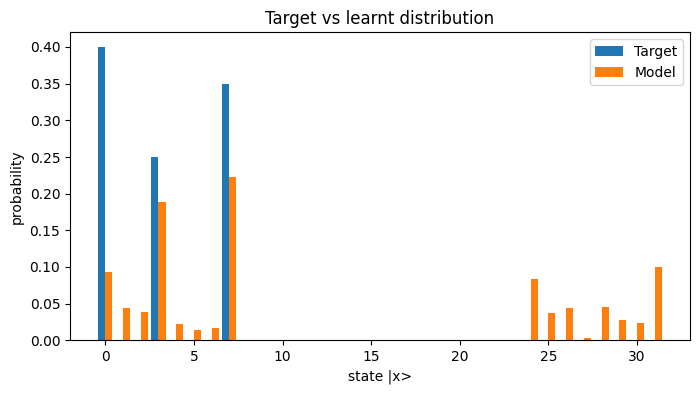

In [11]:
p_final = get_prob_distribution(result.x, ansatz, theta_params)

x = np.arange(dim)

plt.figure(figsize=(8, 4))
plt.bar(x - 0.2, p_target, width=0.4, label="Target")
plt.bar(x + 0.2, p_final, width=0.4, label="Model")
plt.xlabel("state |x>")
plt.ylabel("probability")
plt.title("Target vs learnt distribution")
plt.legend()
plt.show()

# Landscape visualization

In [12]:
def make_mse_objective(ansatz, theta_params, p_target):
    
    def objective(params):
        return mse_loss(params, ansatz, theta_params, p_target)
    
    return objective

objective = make_mse_objective(ansatz, theta_params, p_target)

In [13]:
d1, d2 = lv.random_mixed_directions(len(theta_history[-1]))
paramsf = theta_history[-1]

1D scan progression: 100%|██████████| 3000/3000 [00:01<00:00, 2464.12it/s]


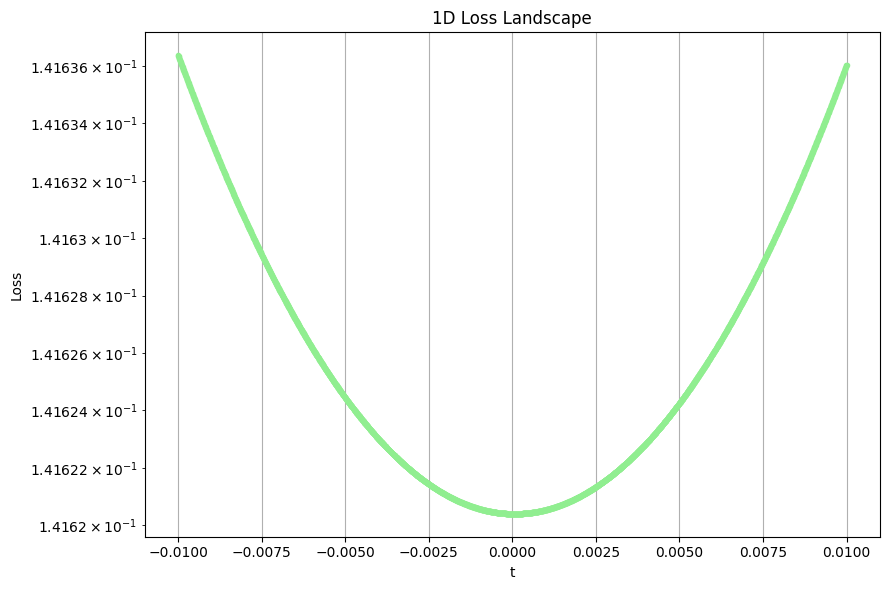

In [14]:
lv.loss_scan_1d(
    params=paramsf,
    direction=d1,
    loss_function=objective,
    n_steps=3000,
    end_points=(-0.01, 0.01),
    n_jobs=-1
)

2D scan progression: 100%|██████████| 300/300 [00:16<00:00, 18.00it/s]


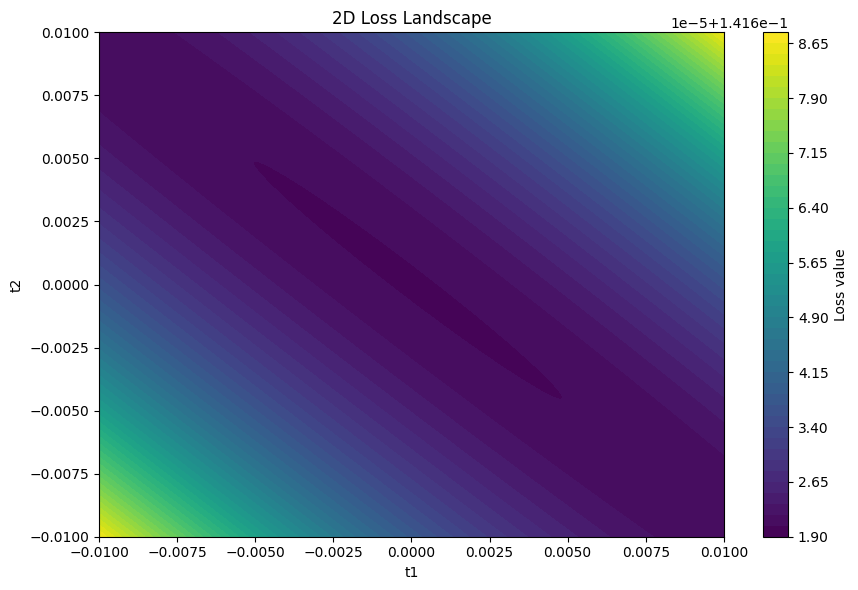

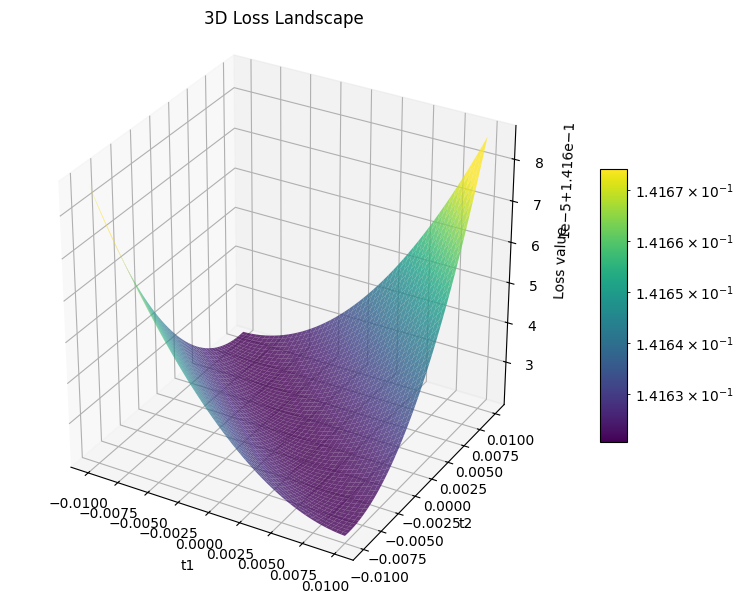

In [15]:
lv.loss_scan_2d_3d(
    params=paramsf,
    direction1=d1,
    direction2=d2,
    loss_function=objective,
    n_steps=300,
    end_points_x=(-0.01, 0.01),
    end_points_y=(-0.01, 0.01),
    plot3D=True,
    n_jobs=-1
)


[PCA] Starting PCA-based loss landscape scan...


Trajectory loss: 100%|██████████| 2379/2379 [00:00<00:00, 4826.98it/s]


[PCA] Plotting 2D PCA loss landscape
[PCA] Plotting 3D PCA loss surface


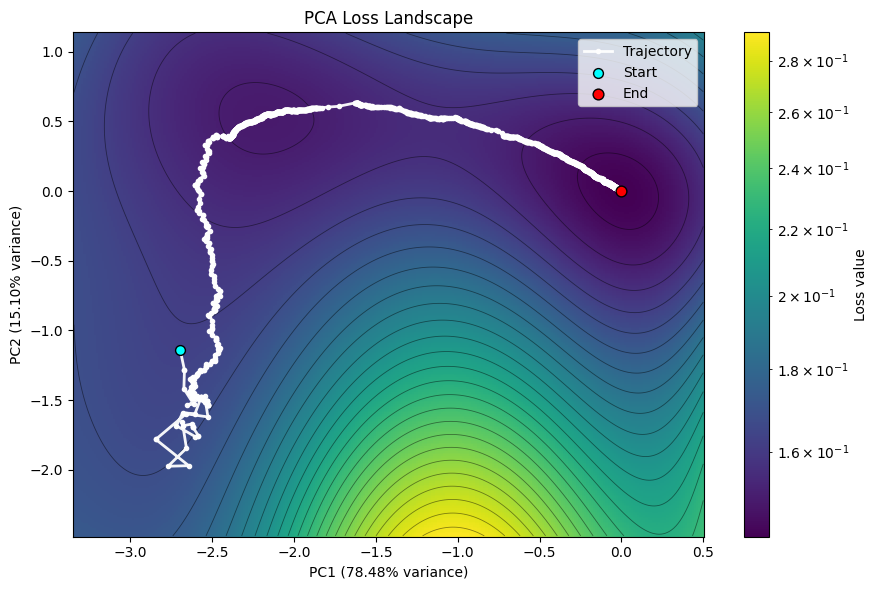

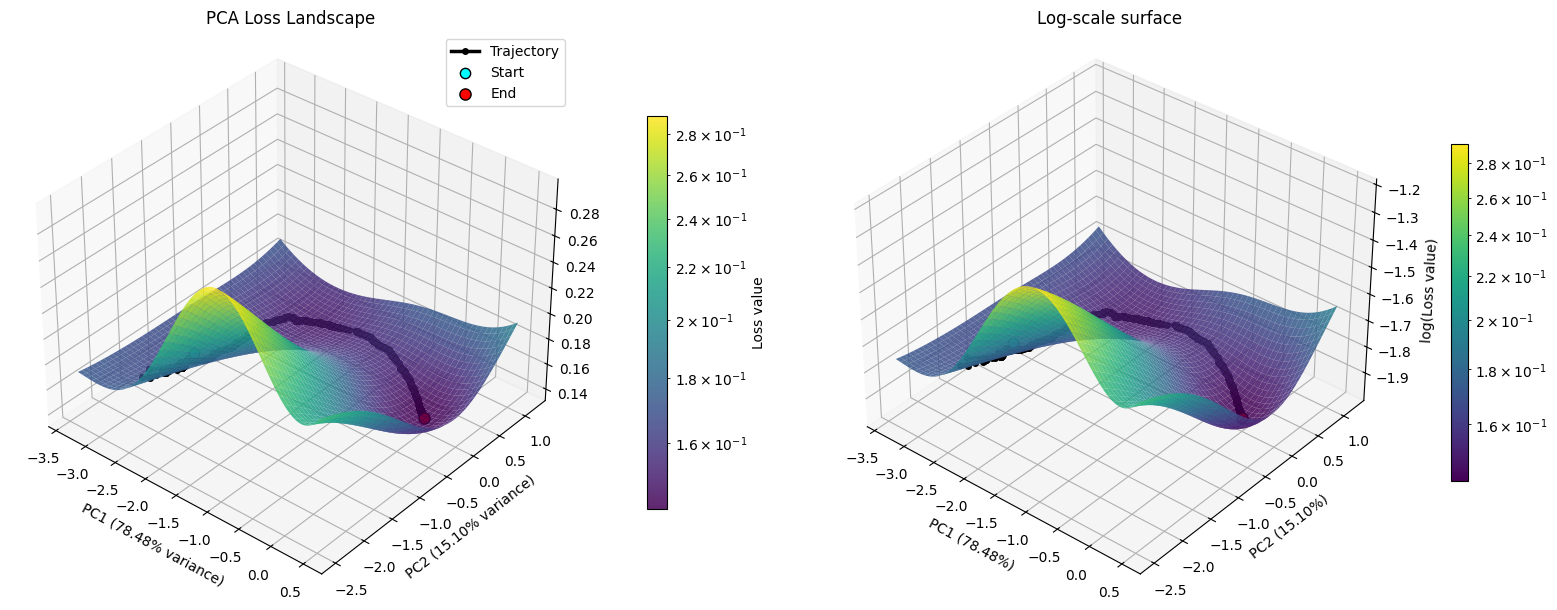


[PCA] Computing interpretable PCA analysis...
[PCA] Visualizing parameter influence on real circuits


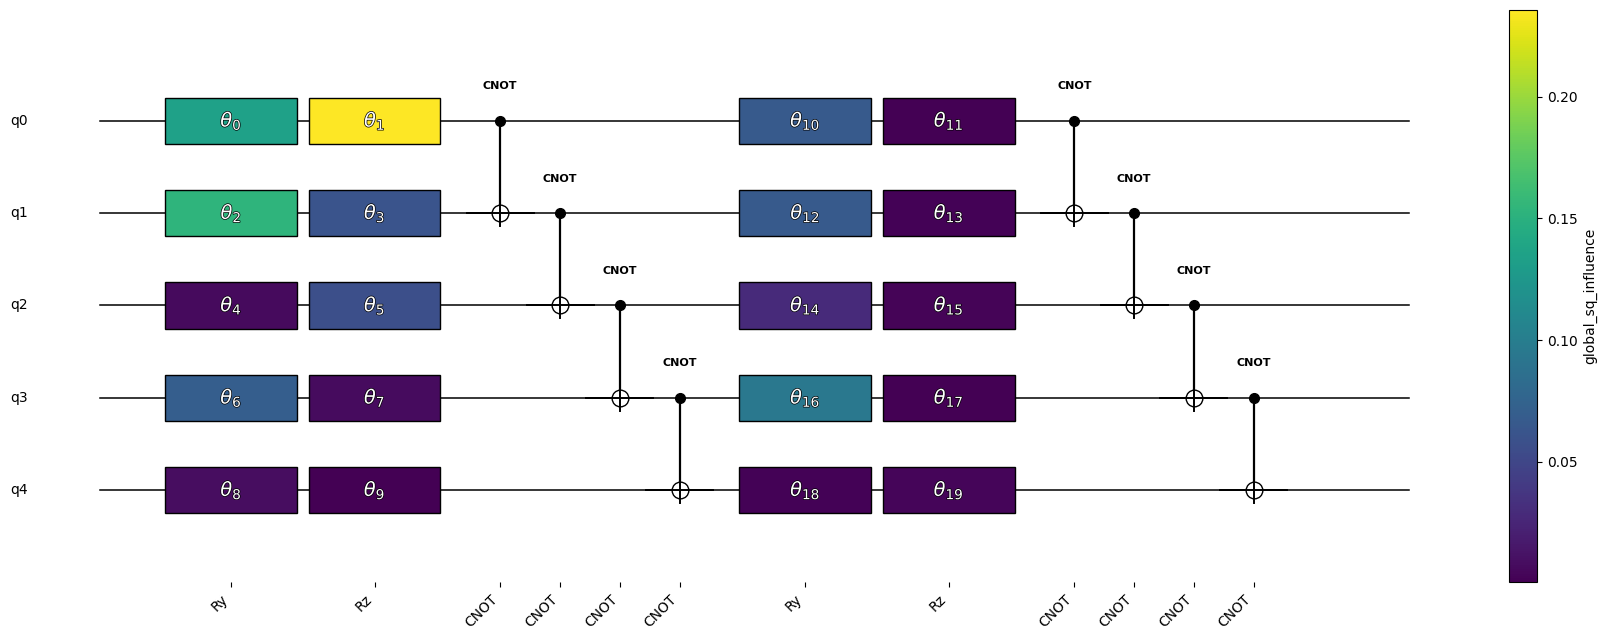

[PCA] Generating global PCA analysis figures


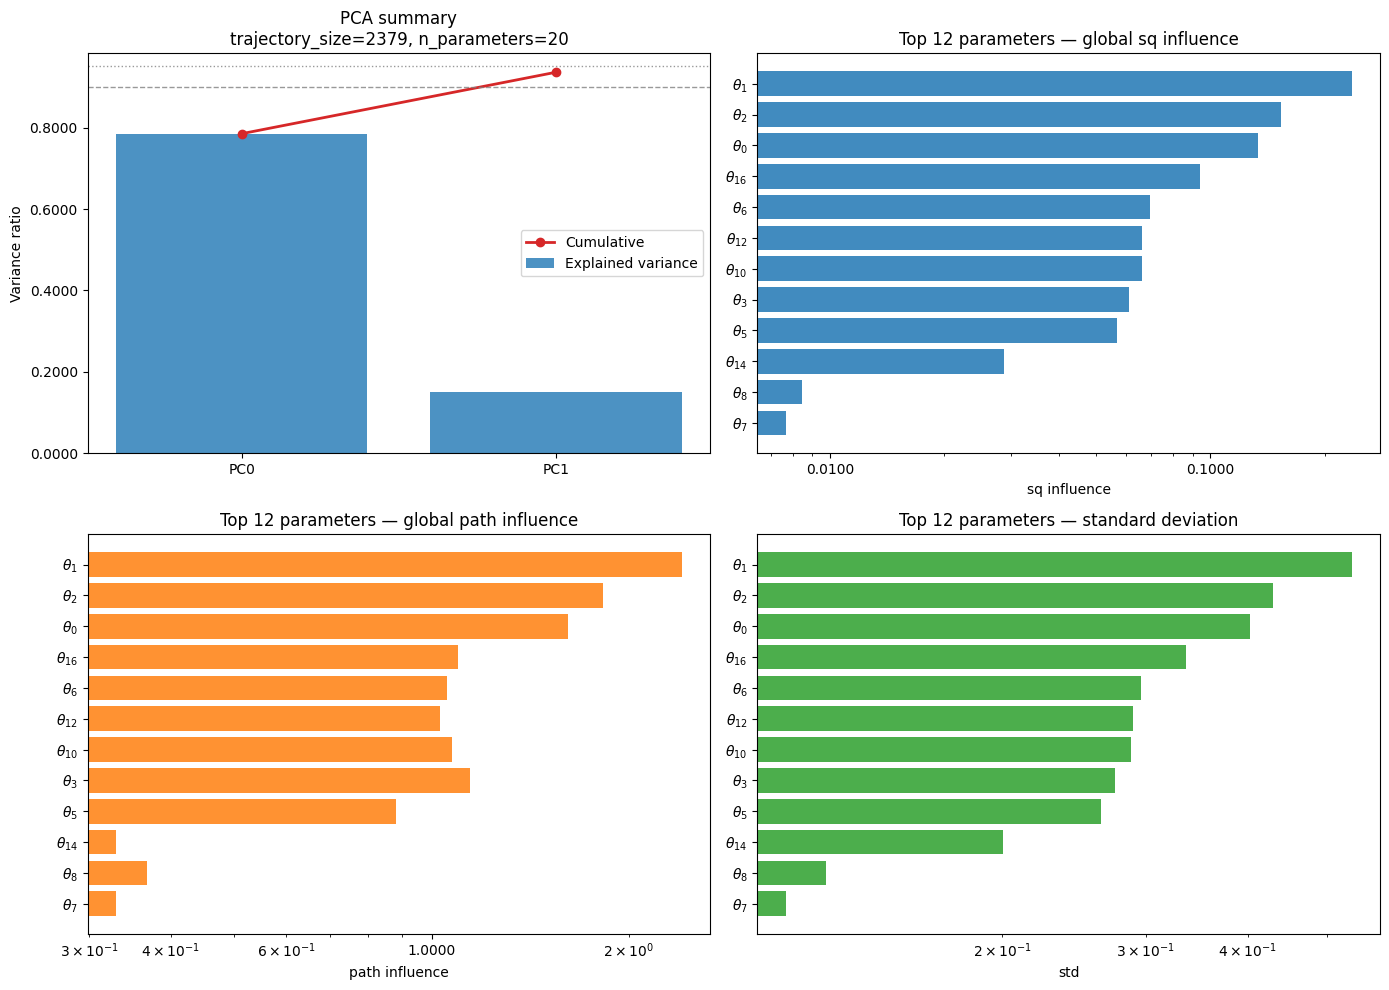

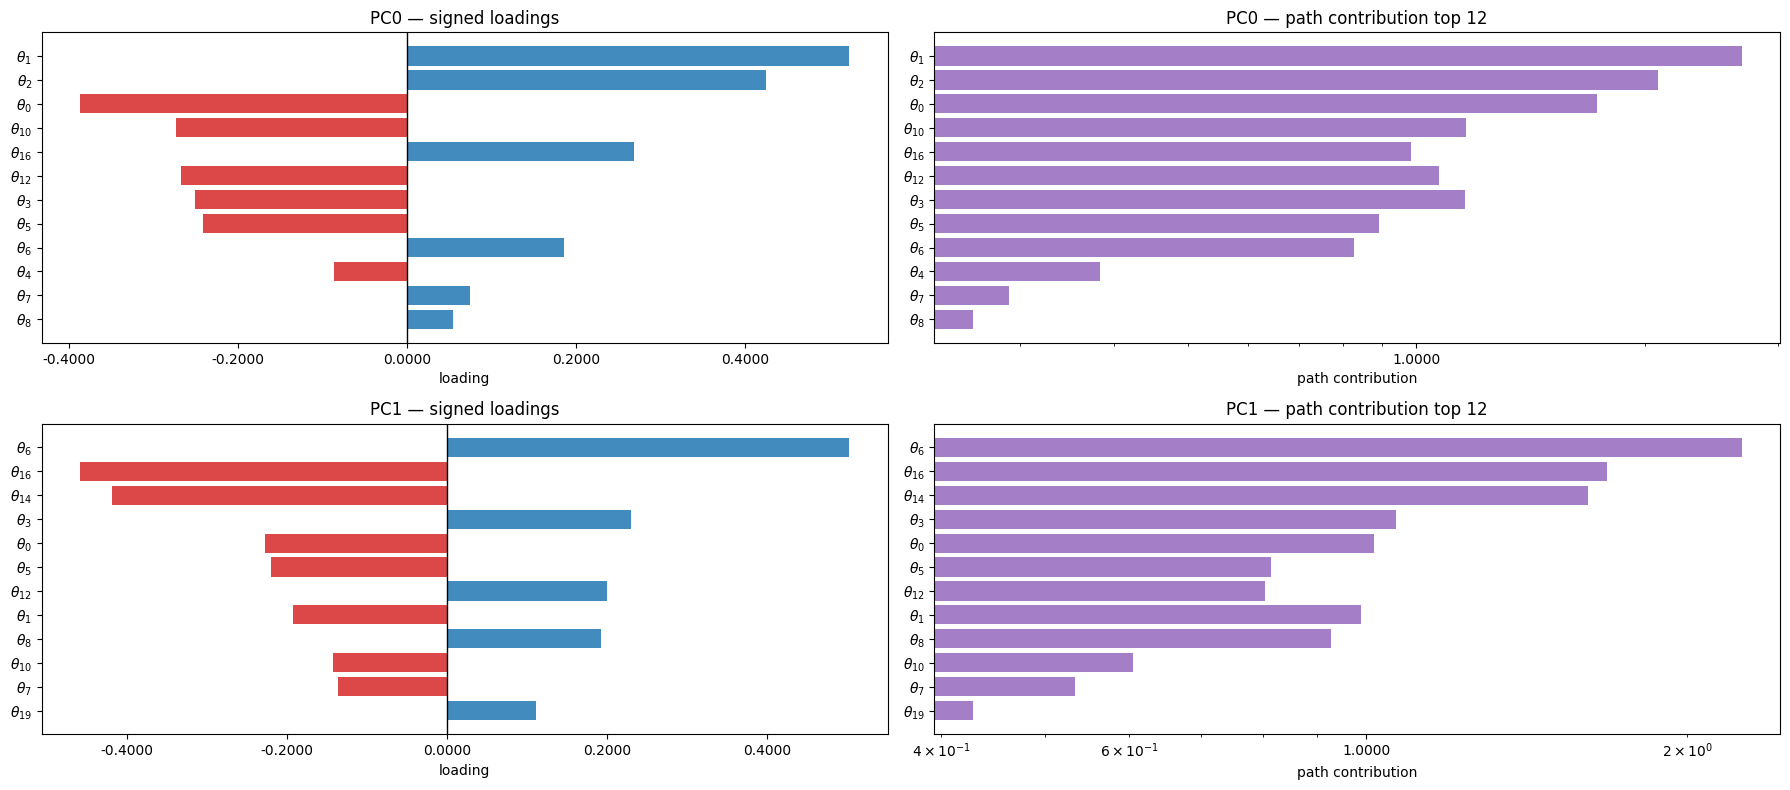

[PCA] Analysis complete


In [17]:
res = lv.perform_pca_and_analysis(
    theta_history,
    objective,
    n_steps=300,
    offset=0.5,
    n_top=12,
    circuit=ansatz,
)